## TFIDF + Logistic Regression

Dataset Shape: (65543, 13)

After dropna: (65543, 2)

After filtering short reviews: (58856, 3)

Label Distribution:
sentiment_label
positive    57333
negative      771
neutral       752
Name: count, dtype: int64

Percentage:
sentiment_label
positive    97.41
negative     1.31
neutral      1.28
Name: proportion, dtype: float64


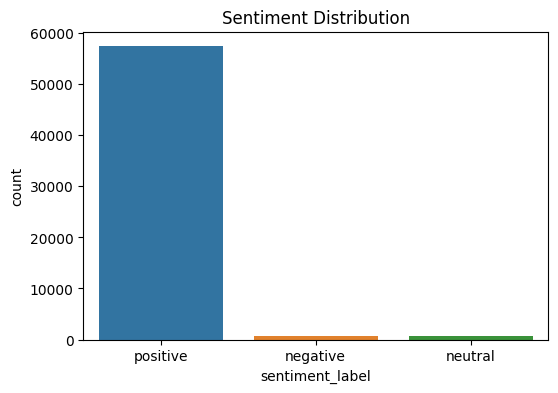


Sample Cleaned Text:
                                         review_text  \
0  baru sekali ini terima brg dr belanja online d...   
1  cocok bgt aku sama telur nya. nga Amis menurut...   
2  Telornya sudah sampai di rumah dengan kemasan ...   
3  Telor sudah diterima dengan baik dan tidak ada...   
4  Alhamdulillah penjual amanah,Telor nya terbaik...   

                                        clean_review  
0  baru sekali ini terima brg dr belanja online d...  
1  cocok bgt aku sama telur nya nga amis menurutk...  
2  telornya sudah sampai di rumah dengan kemasan ...  
3  telor sudah diterima dengan baik dan tidak ada...  
4  alhamdulillah penjual amanahtelor nya terbaiks...  

Label Mapping:
0 = negative
1 = neutral
2 = positive

Train size: 47084
Test size: 11772

TF-IDF Train Shape: (47084, 5000)
TF-IDF Test Shape: (11772, 5000)

Model training completed!

EVALUATION RESULT
Accuracy : 0.7404
Macro F1 : 0.3611

Classification Report:
              precision    recall  f1-score   s

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


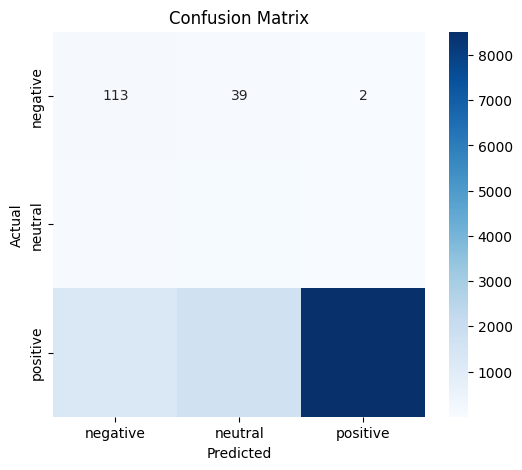


Custom Prediction:

Review: barang bagus banget pengiriman cepat
Predicted Sentiment: positive

Review: produk jelek dan rusak
Predicted Sentiment: negative

Review: lumayan sesuai harga
Predicted Sentiment: neutral


In [4]:
# =====================
# 1. IMPORT LIBRARIES
# =====================

import pandas as pd
import numpy as np
import re
import string
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# 2. LOAD DATASET
# =====================

print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("salmanabdu/tokopedia-product-reviews-2025")
file_path = os.path.join(path, 'tokopedia_product_reviews_2025.csv')

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

# =====================
# 3. PILIH KOLOM YANG DIPAKAI
# =====================

df = df[['review_text', 'sentiment_label']]

# =====================
# 4. HANDLE MISSING VALUES
# =====================

df.dropna(inplace=True)

print("\nAfter dropna:", df.shape)

# =====================
# 5. FILTER REVIEW TERLALU PENDEK
# =====================

df['word_count'] = df['review_text'].astype(str).apply(
    lambda x: len(x.split())
)

df = df[df['word_count'] >= 3]

print("\nAfter filtering short reviews:", df.shape)

# =====================
# 6. CEK DISTRIBUSI LABEL
# =====================

print("\nLabel Distribution:")
print(df['sentiment_label'].value_counts())

print("\nPercentage:")
print(
    round(
        df['sentiment_label'].value_counts(normalize=True) * 100,
        2
    )
)

# =====================
# 7. VISUALISASI IMBALANCE
# =====================

plt.figure(figsize=(6,4))

sns.countplot(
    x=df['sentiment_label']
)

plt.title("Sentiment Distribution")
plt.show()

# =====================
# 8. TEXT PREPROCESSING
# =====================

def clean_text(text):

    text = str(text).lower()

    # hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_review'] = df['review_text'].apply(clean_text)

print("\nSample Cleaned Text:")
print(df[['review_text', 'clean_review']].head())

# =====================
# 9. LABEL ENCODING
# =====================

le = LabelEncoder()

df['label_encoded'] = le.fit_transform(
    df['sentiment_label']
)

print("\nLabel Mapping:")
for i, label in enumerate(le.classes_):
    print(i, "=", label)

# =====================
# 10. FEATURE & LABEL
# =====================

X = df['clean_review']

# PAKAI LABEL ENCODED
y = df['label_encoded']

# =====================
# 11. TRAIN TEST SPLIT
# =====================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

# =====================
# 12. TF-IDF VECTORIZER
# =====================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nTF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

# =====================
# 13. TRAIN MODEL
# =====================

model = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=3000,
    tol=1e-3,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("\nModel training completed!")

# =====================
# 14. PREDICTION
# =====================

y_pred = model.predict(X_test_tfidf)

# =====================
# 15. EVALUATION
# =====================

accuracy = accuracy_score(y_test, y_pred)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("\n====================")
print("EVALUATION RESULT")
print("====================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

# =====================
# 16. CONFUSION MATRIX
# =====================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# =====================
# 17. TEST CUSTOM INPUT
# =====================

sample_reviews = [
    "barang bagus banget pengiriman cepat",
    "produk jelek dan rusak",
    "lumayan sesuai harga"
]

sample_clean = [
    clean_text(x)
    for x in sample_reviews
]

sample_vector = tfidf.transform(sample_clean)

sample_pred = model.predict(sample_vector)

# decode hasil prediksi
sample_pred = le.inverse_transform(sample_pred)

print("\nCustom Prediction:")

for review, pred in zip(sample_reviews, sample_pred):

    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {pred}")